## El Beta (β)

El beta mide qué tan sensible es una acción a los movimientos del mercado.

- **β = 1** : la acción se mueve igual que el mercado
- **β > 1** : la acción amplifica los movimientos del mercado 
- **β < 1** : la acción se mueve menos que el mercado

**Metodología:** calculamos el beta mediante regresión lineal entre los retornos 
mensuales de cada acción y los retornos mensuales del S&P 500, usando los últimos 
60 meses, consistente con la metodología de Yahoo Finance y Bloomberg.

La pendiente de esa regresión **es el beta**.

**¿Por qué mensual y no diario?** Los retornos diarios tienen más ruido. 
Los retornos mensuales capturan mejor la relación estructural entre la acción y el mercado.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from src.yahoo_client import fetch_monthly_returns

In [2]:
TICKERS = ['TSLA', 'F', 'GM', 'RIVN', 'NIO']
START = '2020-01-01'
END = '2025-12-31'

# Mercado mensual
df_mercado_m = fetch_monthly_returns('^GSPC', start=START, end=END)

# Empresas mensual
retornos_m = {}
for ticker in TICKERS:
    retornos_m[ticker] = fetch_monthly_returns(ticker, start=START, end=END)
    print(f"{ticker}: {len(retornos_m[ticker])} meses descargados")

TSLA: 71 meses descargados
F: 71 meses descargados
GM: 71 meses descargados
RIVN: 49 meses descargados
NIO: 71 meses descargados


In [6]:
resultados = []

for ticker in TICKERS:
    df = retornos_m[ticker].join(df_mercado_m['return'], rsuffix='_mercado').dropna()
    
    # Últimos 60 meses
    df = df.tail(60)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df['return_mercado'], 
        df['return']
    )
    
    resultados.append({
        'ticker': ticker,
        'beta': round(slope, 2),
        'r2': round(r_value**2, 2),
        'observaciones': len(df)
    })

df_betas = pd.DataFrame(resultados)
print(df_betas)

  ticker  beta    r2  observaciones
0   TSLA  1.83  0.21             60
1      F  1.63  0.36             60
2     GM  1.32  0.33             60
3   RIVN  1.78  0.14             49
4    NIO  1.06  0.04             60


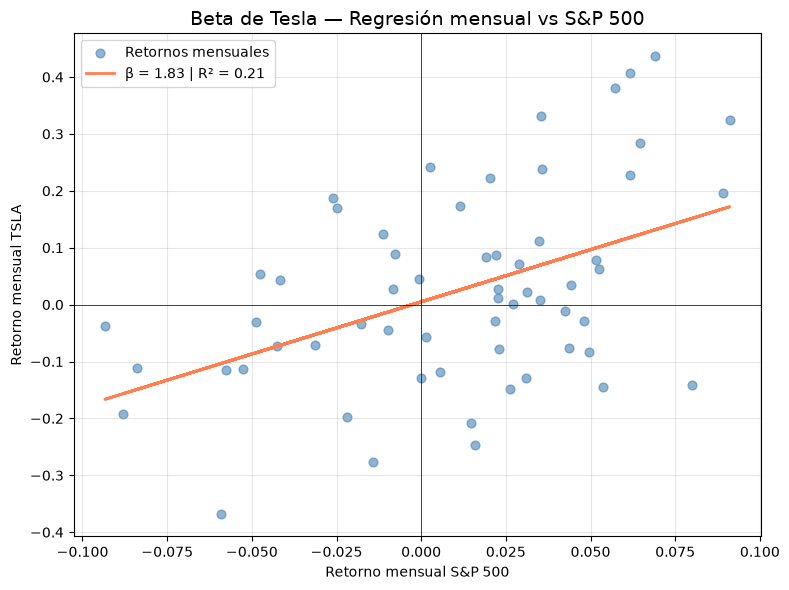

In [7]:
df_tsla_m = retornos_m['TSLA'].join(df_mercado_m['return'], rsuffix='_mercado').dropna().tail(60)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_tsla_m['return_mercado'],
    df_tsla_m['return']
)

x = df_tsla_m['return_mercado']
y_pred = slope * x + intercept

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, df_tsla_m['return'], alpha=0.6, color='steelblue', s=40, label='Retornos mensuales')
ax.plot(x, y_pred, color='coral', linewidth=2, label=f'β = {slope:.2f} | R² = {r_value**2:.2f}')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_title('Beta de Tesla — Regresión mensual vs S&P 500', fontsize=14)
ax.set_xlabel('Retorno mensual S&P 500')
ax.set_ylabel('Retorno mensual TSLA')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()